# Charged Black Holes in Entangled Relativity
## Arnaud Crepinge - M2 Internship

### Null Geodesics Analysis

### Normalizing wrt Horizon

In [1]:
# Import libraries

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

# Font for plotting

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})

## 1 - Definitions

In [2]:
# Horizons in GR

def rpm_GR(M, Q):
    sqrt = sp.sqrt if isinstance(M, sp.Basic) else np.sqrt
    disc = sqrt(M**2 - Q**2)
    return M + disc, M - disc

# Horizons in ER

def rpm_ER(M, Q):
    disc = np.sqrt(M**2 - (11/12) * Q**2)
    return M + disc, (13/11) * (M - disc)

def rpm_ER_sym(M, Q):
    disc = sp.sqrt(M**2 - sp.Rational(11, 12) * Q**2)
    return M + disc, sp.Rational(13, 11) * (M - disc)

# Effective Potential in GR

def Veff_GR(r, M, Q):
    rp, rm = rpm_GR(M,Q)
    return (1 / r**2) * (1 - rm/r) * (1 - rp/r)

# Effective Potential in ER

def Veff_ER(r, M, Q):
    rp, rm = rpm_ER(M,Q)
    return (1 / r**2) * (1 - rp/r) * (1 - rm/r)**(9/13)

# Areal radius ρ as a function of coordinate radius r
# In GR : g_φφ = r² sin²θ  →  ρ = r
# In ER : g_φφ = r²(1 - rm/r)^(2/13) sin²θ  →  ρ = r(1 - rm/r)^(1/13)

def rho_GR(r, M, Q): 
    return r
    
def rho_ER(r, M, Q):
    _, rm = rpm_ER(M, Q)
    return r * (1 - rm / r) ** (1 / 13)

def r_coord(rho, M, Q):
    rp, rm = rpm_ER(M, Q)
    if np.isclose(Q, 0):
        return rho
    if np.isclose(rho, 0):
        return rm
    return brentq(lambda x: rho_ER(x, M, Q) - rho, rm, rho + 2*rp)

# Derivative of rho wrt r

def drho_dr_GR(r, M, Q):
    return 1

def drho_dr_ER(r, M, Q):
    _, rm = rpm_ER(M, Q)
    u = (1 - rm / r)**(-12/13)
    return u * (1 - (12 * rm) / (13 * r))

### Computing the Christoffel Symbols

In [3]:
# Coordinates & Parameters

t, r, th, ph = sp.symbols('t r theta phi', real=True, positive=True)
M, Q         = sp.symbols('M Q', real=True, positive=True)

coords  = [t, r, th, ph]
params  = [M, Q]
all_sym = coords + params

# Metric for GR -> Reissner-Nordström

rp_GR, rm_GR = rpm_GR(M,Q)
f = (1 - rm_GR/r) * (1 - rp_GR/r)

g_GR = sp.Matrix([
    [-f, 0, 0, 0],
    [0, 1/f, 0, 0],
    [0, 0, r**2, 0],
    [0, 0, 0, r**2 * sp.sin(th)**2]
])

# Metric for ER

rp_ER, rm_ER = rpm_ER_sym(M,Q)
f = (1 - rp_ER/r) * (1 - rm_ER/r)**sp.Rational(11, 13)
f2 = (1 - rm_ER/r)**sp.Rational(2, 13)

g_ER = sp.Matrix([
    [-f, 0, 0, 0],
    [0, 1/f, 0, 0],
    [0, 0, r**2 * f2, 0],
    [0, 0, 0, r**2 * sp.sin(th)**2 * f2]
])

# Computing Christoffel Symbols

def compute_christoffel_sym(g, coords):
    n   = len(coords)
    g_inv = g.inv()
    
    # ∂_σ g_μν  — precomputed once
    dg = [[[sp.diff(g[m, n_], coords[s]) for s in range(n)]
            for n_ in range(n)]
           for m in range(n)]
    
    G = [[[None]*n for _ in range(n)] for _ in range(n)]
    for mu in range(n):
        for al in range(n):
            for be in range(al, n):          # exploit symmetry Γ^μ_αβ = Γ^μ_βα
                s = sum(
                    g_inv[mu, nu] * (dg[nu][be][al] + dg[nu][al][be] - dg[al][be][nu])
                    for nu in range(n)
                )
                expr = sp.radsimp(sp.powsimp(s / 2, force=True))
                G[mu][al][be] = expr
                G[mu][be][al] = expr         # symmetry copy
    return G

print("Computing Christoffel symbols for GR... ", end="", flush=True)
G_GR = compute_christoffel_sym(g_GR, coords)
print("Computing Christoffel symbols for ER... ", end="", flush=True)
G_ER = compute_christoffel_sym(g_ER, coords)
print("done")

Computing Christoffel symbols for GR... Computing Christoffel symbols for ER... done


In [4]:
# Lambdify to obtain functions

G_num_GR = sp.lambdify(all_sym, sp.Array(G_GR), "numpy")
G_num_ER = sp.lambdify(all_sym, sp.Array(G_ER), "numpy")

g_num_GR = sp.lambdify(all_sym, g_GR, "numpy")

g_num_ER = sp.lambdify(all_sym, g_ER, "numpy")

### Solving Equations

In [5]:
def geodesic_rhs(lam, state, G_num, M_val, Q_val): 
    x = state[:4]
    k = state[4:]
    args = (*x, M_val, Q_val)

    G = np.array(G_num(*args), dtype=float)  # single call, 64x fewer Python-level dispatches

    # Faster — pure NumPy
    dk = -np.einsum('mab,a,b->m', G, k, k)
    return np.concatenate([k, dk])


def fix_kt(x0, kr, kth, kph, g_num, M_val, Q_val):
    args  = (*x0, M_val, Q_val)
    g_mat = np.array(g_num(*args), dtype=float)
    A = -g_mat[0, 0]
    B = g_mat[1,1]*kr**2 + g_mat[2,2]*kth**2 + g_mat[3,3]*kph**2
    return np.sqrt(B / A)

# Check normalization

def check_normalization(sol, g_num, M_val, Q_val, target=0.0):
    norms = np.zeros(sol.y.shape[1])
    for i in range(sol.y.shape[1]):
        x = sol.y[:4, i]
        k = sol.y[4:, i]
        g = np.array(g_num(*x, M_val, Q_val), dtype=float)
        norms[i] = np.einsum('mn,m,n->', g, k, k)
    return norms - target   # deviation from expected value

## 2 - Plotting Trajectories

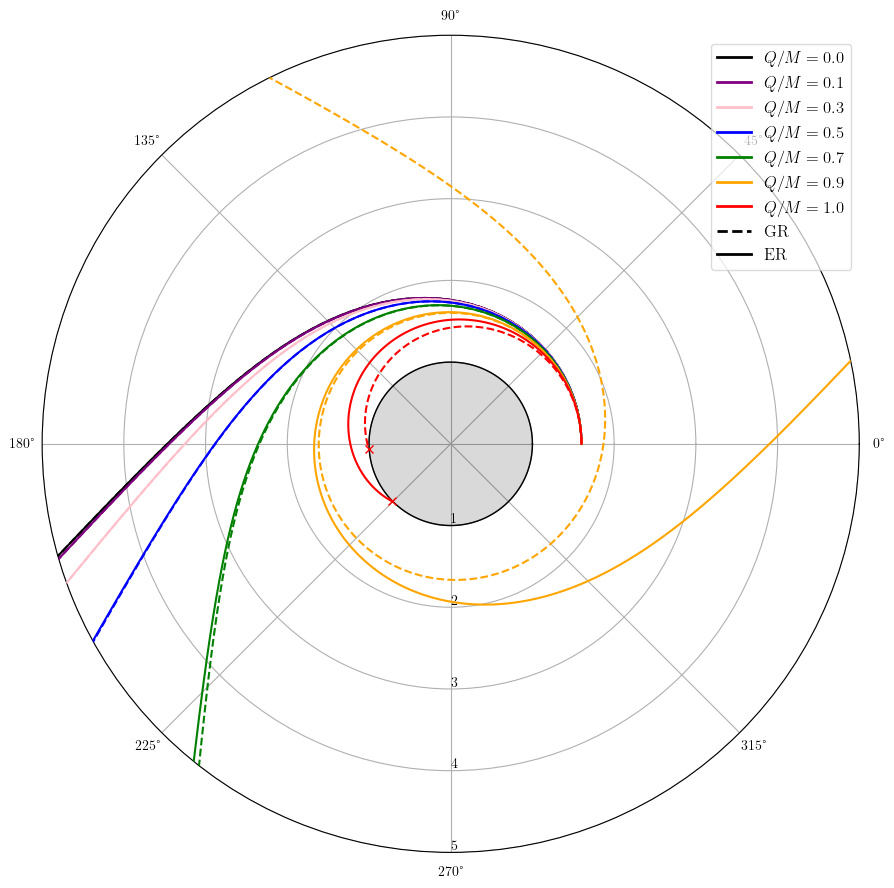

In [6]:
### ── Parameters ────────────────────────────────────────────────────────────────
# Format: (M, Q, color, label)
cases = [
    (1.0, 0.0, 'black',  r'$Q/M = 0.0$'),
    (1.0, 0.1, 'purple', r'$Q/M = 0.1$'),
    (1.0, 0.3, 'pink',   r'$Q/M = 0.3$'),
    (1.0, 0.5, 'blue',   r'$Q/M = 0.5$'),
    (1.0, 0.7, 'green',   r'$Q/M = 0.7$'),
    (1.0, 0.9, 'orange', r'$Q/M = 0.9$'),
    (1.0, 1.0, 'red',    r'$Q/M = 1.0$')
]

rho_init = 1.6 # Must be strictly greater than 1

# Master Physical Initial Conditions
krho   = 0   # Radial velocity
kph  = 1.  # Angular velocity

# ── Absorption event factory ───────────────────────────────────────────────────
def make_absorption_event(rp_val):
    def absorbed(lam, s):
        return s[1] - rp_val * 1.005  # Stops just outside the coordinate horizon
    absorbed.terminal  = True
    absorbed.direction = -1
    return absorbed

# ── Solver ────────────────────────────────────────────────────────────────────
def solve_geodesic(G_num, g_num, rpm_func, M_val, Q_val, kr, kph, r0, lam_max=15, n_pts=20000):
    x0 = np.array([0.0, r0, np.pi/2, 0.0])
    kt = fix_kt(x0, kr, 0.0, kph, g_num, M_val, Q_val)
    k0 = np.array([kt, kr, 0.0, kph])

    rp, _ = rpm_func(M_val, Q_val)
    event = make_absorption_event(float(rp))

    sol = solve_ivp(
        fun=lambda lam, s: geodesic_rhs(lam, s, G_num, M_val, Q_val),
        t_span=(0, lam_max),
        y0=np.concatenate([x0, k0]),
        t_eval=np.linspace(0, lam_max, n_pts),
        method="DOP853",
        rtol=1e-10, atol=1e-12,
        events=event,
    )
    return sol

# ── Plot Setup ────────────────────────────────────────────────────────────────
theories = [
    ("GR", G_num_GR, g_num_GR, rpm_GR, rho_GR, drho_dr_GR, '--'),
    ("ER", G_num_ER, g_num_ER, rpm_ER, rho_ER, drho_dr_ER, '-'),
]

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(9, 9))
ax.set_rlabel_position(270)

theta_circle = np.linspace(0, 2*np.pi, 500)

# ── Integrate and Plot ────────────────────────────────────────────────────────
for M_val, Q_val, color, label in cases:
    for theory_name, G_num, g_num, rpm_func, rho_func, drho_dr_func, linestyle in theories:

        # 1. Calculate the physical outer horizon (rho_+) for this specific case
        rp_coord, _ = rpm_func(M_val, Q_val)
        rho_plus = rho_func(rp_coord, M_val, Q_val)

        # 2. Dynamically define the injection point relative to THIS horizon
        rho0_local = rho_init * rho_plus

        kr = krho / drho_dr_func(r_coord(rho0_local, M_val, Q_val), M_val, Q_val)

        # 3. Map that case-specific areal radius to the required coordinate r0
        if theory_name == "GR":
            r0_init = rho0_local
        else:
            r0_init = r_coord(rho0_local, M_val, Q_val)

        # 4. Solve the geodesic equations in terms of coordinate r
        sol = solve_geodesic(G_num, g_num, rpm_func, M_val, Q_val, kr, kph, r0=r0_init)

        # 5. Map coordinate r back to physical rho, then scale by rho_plus
        rho_trajectory = rho_func(sol.y[1], M_val, Q_val)
        rho_scaled = rho_trajectory / rho_plus
        phi_trajectory = sol.y[3]

        # 6. Plot the horizon-scaled physical trajectory
        ax.plot(phi_trajectory, rho_scaled,
                color=color, lw=1.5, linestyle=linestyle, zorder=4)

        # Mark termination points (will land exactly at 1.0 if absorbed!)
        if sol.status == 1:
            ax.plot(phi_trajectory[-1], rho_scaled[-1],
                    'x', color=color, ms=6, zorder=6)

# ── Fix Plot Limits and Horizon Mask ──────────────────────────────────────────
# Since everything is scaled by rho_plus, the horizon circle is ALWAYS at 1.0
ax.fill(theta_circle, np.full_like(theta_circle, 1.0), color='black', alpha=0.15, zorder=2)
ax.plot(theta_circle, np.full_like(theta_circle, 1.0), color='black', linestyle='-', lw=1, zorder=3)


# ── Custom Legends ────────────────────────────────────────────────────────────
color_handles = [Line2D([0], [0], color=c, lw=2, label=lbl) for _, _, c, lbl in cases]
style_handles = [
    Line2D([0], [0], color='black', lw=2, linestyle='--', label=r'GR'),
    Line2D([0], [0], color='black', lw=2, linestyle='-', label=r'ER')
]
handles = color_handles + style_handles
ax.legend(handles=handles, loc="upper right", fontsize=12, framealpha=0.7)

# Set radial limits to focus on the action near the photon sphere
ax.set_rmax(5)

plt.tight_layout()
plt.savefig("images/NullGeodesics_Horizon.png", dpi=150, bbox_inches='tight')

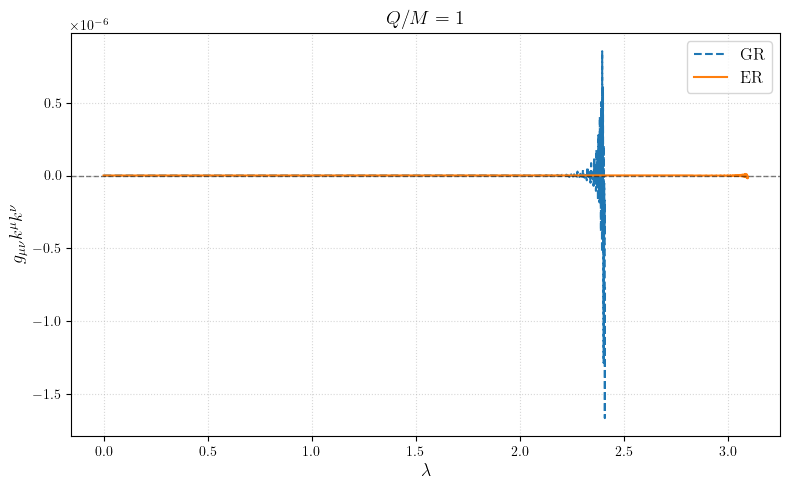

In [7]:
# ── Parameters ────────────────────────────────────────────────────────────────
Q_norm = 1

# Setup a single panel plot
fig, ax = plt.subplots(figsize=(8, 5))

# ── Integrate and Track Normalization ─────────────────────────────────────────
for theory_name, G_num, g_num, rpm_func, rho_func, drho_dr_func, linestyle in theories:
    
    # 1. Dynamically calculate the matching initial coordinate radius r0
    rp_coord, _ = rpm_func(1.0, Q_norm)
    rho_plus = rho_func(rp_coord, 1.0, Q_norm)
    rho0_local = rho_init * rho_plus

    kr = krho / drho_dr_func(r_coord(rho0_local, M_val, Q_val), M_val, Q_val)
    
    if theory_name == "GR":
        r0_init = rho0_local
    else:
        r0_init = r_coord(rho0_local, 1.0, Q_norm)

    # 2. Solve the geodesic system
    sol = solve_geodesic(G_num, g_num, rpm_func, 1.0, Q_norm, kr, kph, r0=r0_init)
    
    # 3. Calculate the actual constraint deviation (should theoretically be 0.0)
    residuals = check_normalization(sol, g_num, 1.0, Q_norm, target=0.0)

    # 4. Plot tracking over the affine parameter lambda
    ax.plot(sol.t, residuals, linestyle=linestyle, lw=1.5, label=theory_name)

# ── Plot Styling ──────────────────────────────────────────────────────────────
ax.set_xlabel(r"$\lambda$", fontsize=13)
ax.set_ylabel(r"$g_{\mu\nu}k^\mu k^\nu$", fontsize=13)
ax.set_title(f"$Q/M = {Q_norm}$", fontsize=14)

# Draw an explicit ideal baseline at 0
ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)

ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()

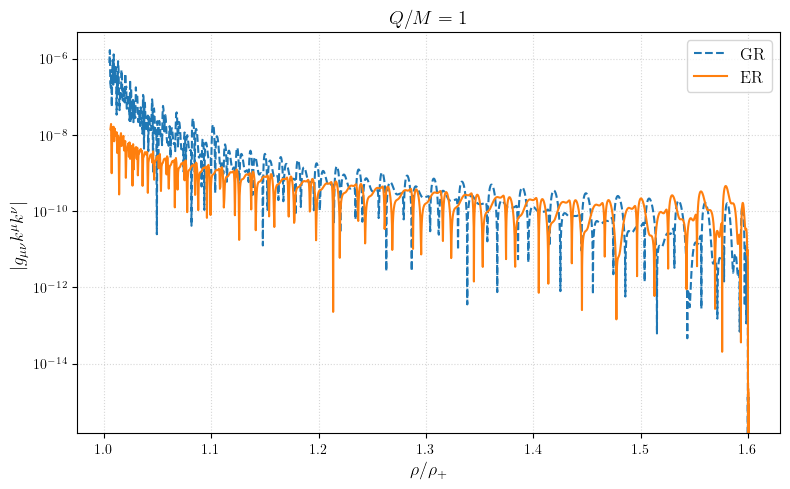

In [8]:
# ── Parameters ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# ── Integrate and Track Normalization vs Radius ───────────────────────────────
for theory_name, G_num, g_num, rpm_func, rho_func, drho_dr_func, linestyle in theories:
    
    # 1. Dynamically calculate matching initial coordinate radius r0
    rp_coord, _ = rpm_func(1.0, Q_norm)
    rho_plus = rho_func(rp_coord, 1.0, Q_norm)
    rho0_local = rho_init * rho_plus  

    kr = krho / drho_dr_func(r_coord(rho0_local, 1, Q_norm), 1, Q_norm)
    
    if theory_name == "GR":
        r0_init = rho0_local
    else:
        r0_init = r_coord(rho0_local, 1.0, Q_norm)

    # 2. Solve the geodesic system
    sol = solve_geodesic(G_num, g_num, rpm_func, 1.0, Q_norm, kr, kph, r0=r0_init)
    
    # 3. Extract physical areal radius profile and constraint residuals
    rho_trajectory = rho_func(sol.y[1], 1.0, Q_norm) / rho_plus
    residuals = check_normalization(sol, g_num, 1.0, Q_norm, target=0.0)

    # 4. Plot absolute error vs Real Physical Distance on a Log Scale
    ax.plot(rho_trajectory, np.abs(residuals), linestyle=linestyle, lw=1.5, label=theory_name)

# ── Plot Styling ──────────────────────────────────────────────────────────────
ax.set_xlabel(r"$\rho / \rho_+$", fontsize=13)
ax.set_ylabel(r"$|g_{\mu\nu}k^\mu k^\nu|$", fontsize=13)
ax.set_title(f"$Q/M = {Q_norm}$", fontsize=14)

# Use log scale to clearly separate exponential growth from flat freezing
ax.set_yscale('log') 
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("images/Error_Horizon.png", dpi=150, bbox_inches='tight')

## 3 - Effective Potential Analysis

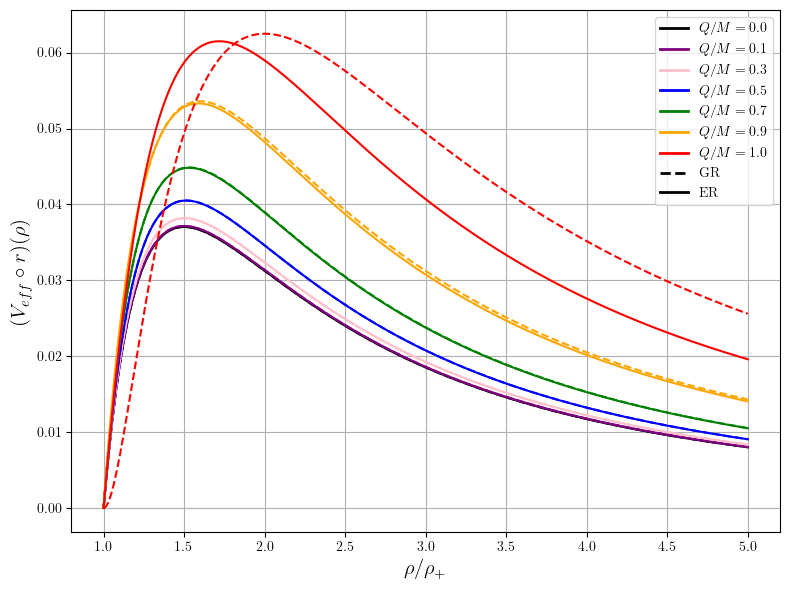

In [9]:
plt.figure(figsize=(8, 6))

for m, q, c, s in cases:
    rpGR, _ = rpm_GR(m, q)
    rpER, _ = rpm_ER(m, q)
    
    r_GR = np.linspace(rpGR, 5 * rpGR, 1000)
    r_GR_norm = r_GR / rpGR

    rhopER = rho_ER(rpER, m, q)
    rhoER = np.linspace(rhopER, 5 * rhopER, 1000)
    rhoER_norm = rhoER / rhopER

    r_ER = np.array([r_coord(rho, m, q) for rho in rhoER])
    
    Vgr = np.array([Veff_GR(r, m, q) for r in r_GR])
    Ver = np.array([Veff_ER(r, m, q) for r in r_ER])

    plt.plot(r_GR_norm, Vgr, '--', color=c)
    plt.plot(rhoER_norm, Ver, '-', color=c)


plt.legend(handles=handles,loc="upper right", fontsize=10)

plt.grid()
plt.xlabel(r'$\rho/ \rho_+$', fontsize=15)
plt.ylabel(r'$(V_{eff} \circ r)(\rho)$', fontsize=15)

plt.tight_layout()
plt.savefig("images/EffectivePotentials_Horizon.png", dpi=150, bbox_inches='tight')

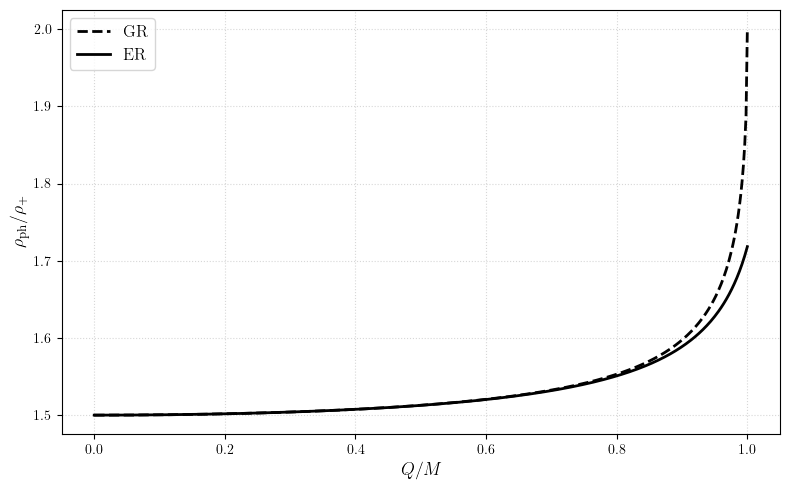

In [10]:
## 4 - Photon Sphere Radius vs Charge

M_val = 1.0
Q_arr_GR = np.linspace(0, 1.0, 500)
Q_arr_ER = np.linspace(0, 1.0, 500)

# ── Analytical photon sphere in GR (Reissner-Nordström) ───────────────────────
def r_photon_GR(M, Q):
    return (3*M + np.sqrt(np.maximum(9*M**2 - 8*Q**2, 0))) / 2

# ── Analytical photon sphere in ER ───────────────────────────────
def r_photon_ER(M, Q):
    rp, rm = rpm_ER(M, Q)
    a = (35/13) * rm + 3 * rp
    b = 8 * (48/13) * rm * rp
    return (1/4) * (a + np.sqrt(a**2 - b))

# ── Compute ρ_ph and ρ_+ for each Q ──────────────────────────────────────────
rho_ph_GR   = np.array([rho_GR(r_photon_GR(M_val, Q), M_val, Q)  for Q in Q_arr_GR])
rho_plus_GR = np.array([rho_GR(rpm_GR(M_val, Q)[0],   M_val, Q)  for Q in Q_arr_GR])

r_ph_ER_arr = np.array([r_photon_ER(M_val, Q)                     for Q in Q_arr_ER])
rho_ph_ER   = np.array([rho_ER(r, M_val, Q) if not np.isnan(r) else np.nan
                         for r, Q in zip(r_ph_ER_arr, Q_arr_ER)])
rho_plus_ER = np.array([rho_ER(rpm_ER(M_val, Q)[0], M_val, Q)    for Q in Q_arr_ER])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(Q_arr_GR, rho_ph_GR / rho_plus_GR, '--', color='black', lw=2, label='GR')
ax.plot(Q_arr_ER, rho_ph_ER / rho_plus_ER, '-',  color='black', lw=2, label='ER')

ax.set_xlabel(r'$Q/M$', fontsize=13)
ax.set_ylabel(r'$\rho_{\mathrm{ph}} / \rho_+$', fontsize=13)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig("images/PhotonSphere_Horizon.png", dpi=150, bbox_inches='tight')